## 🫀 CardioRisk AI: Heart Disease Prediction System

### 📌 Problem Statement
Heart disease is one of the leading causes of death worldwide. Early prediction can help in timely treatment.

### 🎯 Objective
Build a machine learning model to predict whether a person has heart disease based on medical attributes.

### 📊 Dataset
- Source: UCI / Kaggle Heart Dataset
- Features: Age, Sex, ChestPainType, Cholesterol, etc.

### 🛠 Tech Stack
- Python, Pandas, NumPy
- Scikit-learn
- Matplotlib, Seaborn

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



In [69]:
df=pd.read_csv('heart.csv')

In [70]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [72]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [73]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [74]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [75]:
df.duplicated().sum()

0

In [76]:
df.shape

(918, 12)

In [77]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [78]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


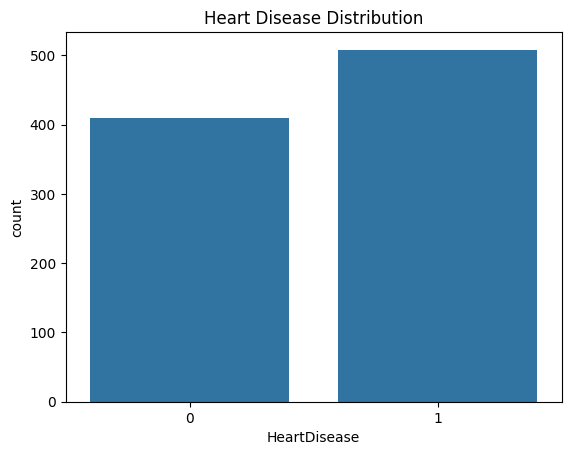

In [79]:
sns.countplot(x='HeartDisease', data=df)
plt.title("Heart Disease Distribution")
plt.show()

### Insight:
- Patients with chest pain type ASY have higher disease probability
- Older age group shows higher risk

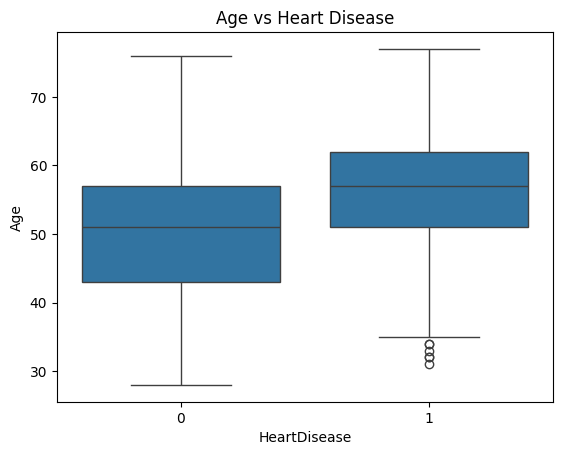

In [80]:
sns.boxplot(x='HeartDisease', y='Age', data=df)
plt.title("Age vs Heart Disease")
plt.show()

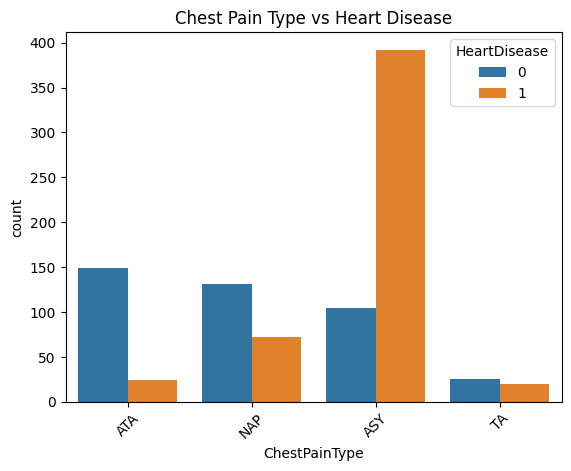

In [81]:
sns.countplot(x='ChestPainType', hue='HeartDisease', data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.xticks(rotation=45)
plt.show()

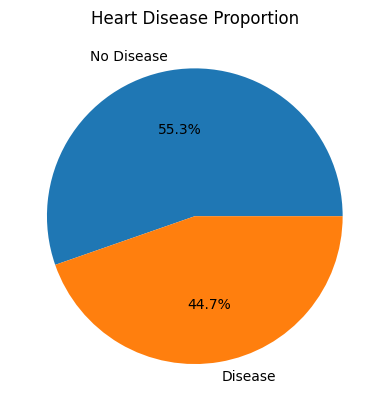

In [82]:
df['HeartDisease'].value_counts().plot.pie(
    autopct='%1.1f%%', labels=['No Disease', 'Disease']
)
plt.title("Heart Disease Proportion")
plt.ylabel('')
plt.show()

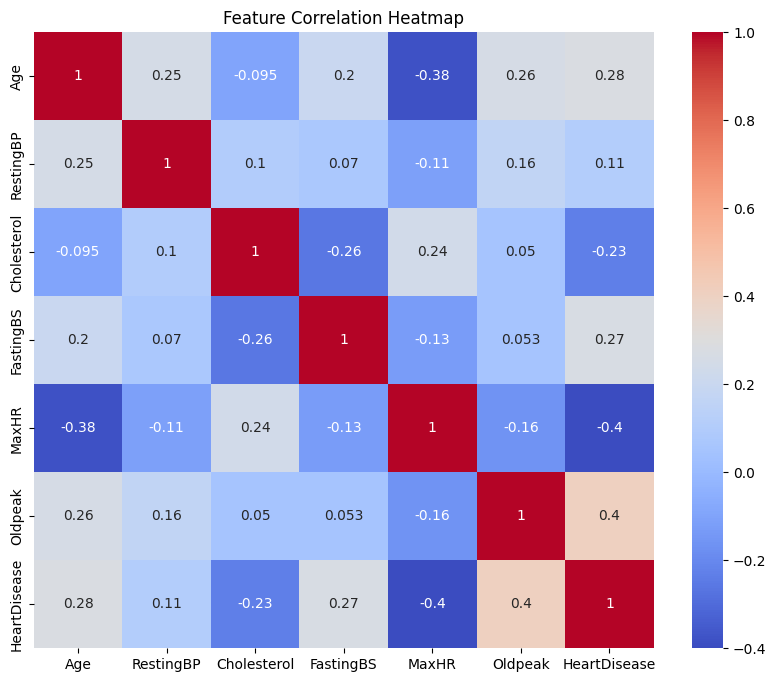

In [83]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [84]:
df_onehot=pd.get_dummies(df,columns=['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope'],drop_first=True)

In [85]:
df_onehot=df_onehot.astype(int)

In [86]:
df_onehot

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [ ]:
X=df_onehot.drop('HeartDisease',axis=1)
Y=df_onehot['HeartDisease']


In [88]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [89]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,Y_train)

LogisticRegression()

In [90]:
y_pred=model.predict(X_test)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(accuracy_score(Y_test,y_pred))
print(classification_report(Y_test,y_pred))
print(confusion_matrix(Y_test,y_pred))


0.8532608695652174
              precision    recall  f1-score   support

           0       0.80      0.86      0.83        77
           1       0.89      0.85      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.86      0.85      0.85       184

[[66 11]
 [16 91]]


## USING KNN MODEL 

In [91]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [92]:
X_train_scaled

array([[-1.24506731, -0.70898547,  0.372803  , ..., -0.83846064,
        -1.03325003, -0.84792072],
       [-1.8862362 , -0.16628515,  0.08614581, ..., -0.83846064,
        -1.03325003,  1.17935554],
       [ 0.25099346,  0.91911549,  0.12313384, ...,  1.19266183,
         0.96781995, -0.84792072],
       ...,
       [ 0.67843939, -0.16628515,  0.49301407, ...,  1.19266183,
        -1.03325003,  1.17935554],
       [ 0.67843939,  1.02765555, -1.84647842, ...,  1.19266183,
        -1.03325003,  1.17935554],
       [-1.45879027,  0.91911549,  1.77834789, ..., -0.83846064,
         0.96781995, -0.84792072]])

In [93]:
from sklearn.neighbors import KNeighborsClassifier

In [94]:
modelknn=KNeighborsClassifier(n_neighbors=17)
modelknn.fit(X_train_scaled,Y_train)

KNeighborsClassifier(n_neighbors=17)

In [95]:
pred_knn=modelknn.predict(X_test_scaled)

In [96]:
print(accuracy_score(Y_test,pred_knn))
print(classification_report(Y_test,pred_knn)) 
print(confusion_matrix(Y_test,pred_knn))

0.8967391304347826
              precision    recall  f1-score   support

           0       0.87      0.88      0.88        77
           1       0.92      0.91      0.91       107

    accuracy                           0.90       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.90      0.90      0.90       184

[[68  9]
 [10 97]]


## USING NAIVE BAYES 


In [97]:
from sklearn.naive_bayes import GaussianNB
model_nb=GaussianNB()


In [98]:
model_nb.fit(X_train_scaled,Y_train)
y_pred_nb=model_nb.predict(X_test_scaled)


In [99]:
print(accuracy_score(Y_test,y_pred_nb))
print(classification_report(Y_test,y_pred_nb))

0.8641304347826086
              precision    recall  f1-score   support

           0       0.81      0.88      0.84        77
           1       0.91      0.85      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.87      0.86       184
weighted avg       0.87      0.86      0.86       184



| Model              | Accuracy |
|------------------|---------|
| Logistic Regression | 85.32% |
| KNN                | 89.67% |
| Naive Bayes        | 86.41% |

## ✅ Conclusion

- Logistic Regression performed best with XX% accuracy
- KNN improved performance after scaling
- Features like ChestPainType and Age are strong indicators

## 🚀 Future Work
- Use Deep Learning
- Deploy as Web App 
- Use larger dataset